# Structured operators — Dense, Diagonal, Kronecker, BlockDiag, LowRankUpdate

A linear operator is anything that turns a vector into another vector linearly. The dense matrix $A\in\mathbb{R}^{n\times n}$ is the universal one — it can represent every operator — but it is also the *most expensive* one. Once $n$ exceeds a few thousand, storing $A$ requires gigabytes and the cubic-cost primitives ($\mathrm{solve}$, $\mathrm{logdet}$, $\mathrm{chol}$) become impossibly slow.

Every Gaussian-process scaling story begins with the same realization: we rarely need a *general* operator. The kernel matrix on a tensor-product grid factorizes as $K_X\otimes K_Y$. The precision of a Markov chain is block tridiagonal. The posterior covariance after a low-rank measurement is $A + UDV^\top$. *Structure is the rule, not the exception* — and once we expose it as the type of the operator, every downstream primitive can dispatch to a cheaper algorithm.

This notebook is the catalog: we tour the five basic operators that show up in 90% of GP code (`MatrixLinearOperator`, `DiagonalLinearOperator`, `Kronecker`, `BlockDiag`, `LowRankUpdate`), compare their per-primitive costs, and end with a "which operator do I reach for" decision table.

What you will see by the end:

- The `lineax.AbstractLinearOperator` interface — matvec, transpose, structural tags — and how `gaussx` extends it.
- The arithmetic identities that make each structured class cheap (Kronecker vec-trick, block-wise solve, Sherman–Morrison–Woodbury).
- A side-by-side cost table that ranks operators by their $\mathrm{matvec}$, $\mathrm{solve}$, and $\mathrm{logdet}$ complexities.
- Theoretical FLOP curves plotted directly from the dispatch table (same approach as notebook 0.9).

By the end you should be able to look at a covariance and say "that's a `Kronecker(BlockDiag, Toeplitz)`" — and know, without writing code, what the inference cost will be.

## 0. Where these structures show up in geoscience

The five operators in this notebook aren't abstractions for their own sake — every one of them maps to a recurring shape in environmental data. A short, non-exhaustive map:

- **Diagonal** — heteroscedastic observation noise: each station / mooring / satellite footprint has its own measurement variance $\sigma_i^2$, and the noise covariance is $\mathrm{diag}(\sigma_1^2,\dots,\sigma_N^2)$. ARD lengthscales for multivariate inputs (latitude, longitude, depth, elevation) ride on a diagonal weighting too.
- **Kronecker** — anything on a regular tensor-product grid: sea-surface temperature on (lat × lon), CO$_2$ flux on (time × space), soil moisture on (depth × horizontal), seismic amplitude on (offset × azimuth). The kernel $K_{\mathrm{lat}}\otimes K_{\mathrm{lon}}$ replaces a dense $N\times N$ covariance with two factor matrices the size of one axis.
- **BlockDiag** — independent geographic regions (river basins, ocean basins, ecoregions) where cross-region correlation is negligible. Multi-output GPs with one block per pollutant species. Ensemble forecasts where members are conditionally independent given parameters.
- **LowRankUpdate** — assimilating $M$ observations into a high-dimensional state, with $M \ll N$. The Kalman update $P^{+} = P^{-} - K H P^{-}$ adds a rank-$M$ correction to the prior covariance; ensemble Kalman filters (EnKF) parameterize the ensemble covariance directly as $\frac{1}{M-1}EE^\top$, which is rank-$M$ low-rank by construction.
- **Dense** — calibration-scale inverse problems with $N \lesssim 10^3$ (gravity / magnetics inversion at coarse resolution, instrument calibration). The fallback when no structure is exploitable.

The composition rule matters too: a Kronecker of BlockDiags is a tensor-product grid where each output channel evolves independently — *exactly* the shape of multivariate spacetime fields like (temperature, salinity) on (lat × lon × depth).

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore", message=r".*IProgress.*")

import einx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import numpy as np
from gaussx import (
    BlockDiag,
    Kronecker,
    LowRankUpdate,
    cholesky,
    diag as gx_diag,
    logdet,
    solve,
    trace as gx_trace,
)
from gaussx._operators._low_rank_update import (
    low_rank_plus_diag,
    low_rank_plus_identity,
)

jax.config.update("jax_enable_x64", True)
KEY = jax.random.PRNGKey(0)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.3,
})

def psd_op(M):
    return lx.MatrixLinearOperator(M, lx.positive_semidefinite_tag)

def random_psd(key, n, jitter=1e-3):
    A = jax.random.normal(key, (n, n))
    return A @ A.T + jitter * jnp.eye(n)

## 1. The `AbstractLinearOperator` interface

`lineax` defines an operator $A$ by what it can *do*, not by how it is stored:

```{math}
:label: eq:op-interface
A : \mathbb{R}^n \to \mathbb{R}^m, \qquad
\texttt{mv}(A, v) = A v, \qquad
\texttt{transpose}(A) = A^\top, \qquad
\texttt{tags}(A) \subseteq \{\text{symmetric}, \text{PSD}, \text{diagonal}, \dots\}
```

Three things follow:

- **Storage is opaque.** A dense `MatrixLinearOperator` stores all $n^2$ entries, but a `Kronecker(A,B)` stores only $\dim(A)^2 + \dim(B)^2$ entries. Both expose the same `mv` interface — primitives don't care.
- **Tags drive dispatch.** When `gaussx.solve` sees an operator carrying the `positive_semidefinite_tag`, it dispatches to Cholesky; when it sees a `Kronecker`, it dispatches to the vec-trick. Tags are how structure becomes free speed.
- **Operators compose.** A `BlockDiag` of `Kronecker`s of `LowRankUpdate`s is a perfectly valid operator — each layer adds its own structural shortcut. This is the whole point of `gaussx`'s Layer-1 stack.

The five basics below are the leaves of every operator tree you will build.

## 2. Dense — `MatrixLinearOperator`

The reference. No structure, no shortcuts: $A$ is stored as an $n\times n$ array, and every primitive falls back to the textbook algorithm.

```{math}
:label: eq:dense-cost
\text{matvec}: O(n^2), \qquad
\text{solve}: O(n^3), \qquad
\text{logdet}: O(n^3), \qquad
\text{storage}: O(n^2)
```

Use it when $n \lesssim 10^3$, or when there is genuinely no structure to exploit. Everything else in this notebook is a strategy for *avoiding* the dense fallback.

In [2]:
key = jax.random.PRNGKey(0)
M = random_psd(key, 6)
A = psd_op(M)
print("type :", type(A).__name__)
print("shape:", (A.out_size(), A.in_size()))
print("tags :", A.tags)
print("matvec test:")
v = jnp.ones(6)
print("  A v =", A.mv(v))
print("logdet =", float(logdet(A)))

type : MatrixLinearOperator
shape: (6, 6)
tags : frozenset({positive_semidefinite_tag})
matvec test:
  A v = [ 5.87017962  8.03242941 10.23166161  4.59710352 18.53830139 26.15230753]


logdet = 6.858822784367429


## 3. Diagonal — the trivial structure

A diagonal operator $D = \mathrm{diag}(d_1,\dots,d_n)$ is the warm-up: every primitive collapses to an element-wise operation on the diagonal vector.

```{math}
:label: eq:diag-primitives
D v = d \odot v, \qquad
D^{-1} b = b / d, \qquad
\log|D| = \sum_{i=1}^n \log d_i, \qquad
\mathrm{tr}(D) = \sum_{i=1}^n d_i
```

Cost is linear in $n$ across the board. Storage is $O(n)$ — the diagonal vector itself.

Diagonal operators show up everywhere: noise covariances $\sigma^2 I$, ARD lengthscale weights, mean-field variational families, preconditioners. `lineax` provides `DiagonalLinearOperator` and `IdentityLinearOperator` directly; `gaussx` recognizes them via the `diagonal_tag`.

In [3]:
d = jnp.array([1.0, 2.0, 3.0, 4.0])
D = lx.DiagonalLinearOperator(d)
print("type :", type(D).__name__)
print("D v  :", D.mv(jnp.ones(4)))
print("logdet =", float(logdet(D)), "vs sum log d =", float(jnp.sum(jnp.log(d))))
print("trace  =", float(gx_trace(D)), "vs sum d    =", float(jnp.sum(d)))

type : DiagonalLinearOperator
D v  : [1. 2. 3. 4.]


logdet = 3.1780538303479453 vs sum log d = 3.1780538303479453
trace  = 10.0 vs sum d    = 10.0


## 4. Kronecker — separable structure

Whenever the covariance factorizes across independent input axes (a 2-D grid in space, time × feature), the kernel matrix becomes a Kronecker product:

```{math}
:label: eq:kron-def
A \otimes B = \begin{bmatrix} a_{11}B & \cdots & a_{1n}B \\ \vdots & \ddots & \vdots \\ a_{n1}B & \cdots & a_{nn}B \end{bmatrix} \in \mathbb{R}^{nm\times nm}
```

The dense form has $(nm)^2$ entries, but the operator only needs $n^2 + m^2$. The savings come from **Roth's vec-lemma**:

```{math}
:label: eq:kron-vec
(A \otimes B)\,\mathrm{vec}(X) = \mathrm{vec}(B X A^\top), \qquad X \in \mathbb{R}^{m\times n}
```

A matvec on a vector of length $nm$ becomes two matrix-multiplies of size $m\times n$ — total cost $O(nm(n+m))$ instead of $O((nm)^2)$. Solve and logdet inherit the same factorization:

```{math}
:label: eq:kron-solve-logdet
(A\otimes B)^{-1} = A^{-1}\otimes B^{-1}, \qquad \log|A\otimes B| = m\log|A| + n\log|B|
```

For $n=m=64$ the dense matvec is $\sim 16\text{M}$ flops; the Kronecker matvec is $\sim 0.5\text{M}$ — a 30× speedup that grows with size.

In [4]:
kA, kB = jax.random.split(jax.random.PRNGKey(1))
A_mat = random_psd(kA, 5)
B_mat = random_psd(kB, 4)
A_op = psd_op(A_mat)
B_op = psd_op(B_mat)

K = Kronecker(A_op, B_op)
K_dense = jnp.kron(A_mat, B_mat)
v = jax.random.normal(jax.random.PRNGKey(2), (20,))

err_mv = jnp.linalg.norm(K.mv(v) - K_dense @ v)
err_ld = float(logdet(K)) - float(jnp.linalg.slogdet(K_dense)[1])
print(f"matvec error : {err_mv:.2e}")
print(f"logdet error : {err_ld:.2e}")
print(f"Kronecker storage : {A_mat.size + B_mat.size} floats")
print(f"Dense storage     : {K_dense.size} floats  ({K_dense.size / (A_mat.size+B_mat.size):.0f}x larger)")

matvec error : 1.77e-14
logdet error : 2.66e-14
Kronecker storage : 41 floats
Dense storage     : 400 floats  (10x larger)


## 5. BlockDiag — independent sub-problems

A block-diagonal operator partitions the input into $K$ independent groups, each handled by its own (possibly structured) sub-operator:

```{math}
:label: eq:blockdiag-def
\mathrm{BlockDiag}(A_1, \dots, A_K) = \begin{bmatrix} A_1 & & \\ & \ddots & \\ & & A_K \end{bmatrix}
```

Every primitive decomposes block-wise:

```{math}
:label: eq:blockdiag-solve
\mathrm{BlockDiag}^{-1} = \mathrm{BlockDiag}(A_1^{-1}, \dots, A_K^{-1}), \qquad
\log|\mathrm{BlockDiag}| = \sum_{k=1}^K \log|A_k|
```

If each block has size $b = n/K$, dense solve drops from $O(n^3)$ to $O(K b^3) = O(n^3/K^2)$ — embarrassingly parallel. Crucially, the blocks need not be dense: a `BlockDiag` of `Kronecker`s is the canonical multi-output / batched-GP structure.

In [5]:
ks = jax.random.split(jax.random.PRNGKey(3), 3)
blocks = [psd_op(random_psd(k, n)) for k, n in zip(ks, [4, 3, 5])]
BD = BlockDiag(*blocks)
print("BlockDiag size:", BD.out_size())
print("Per-block sizes:", [b.out_size() for b in blocks])

# logdet decomposes
ld_total = float(logdet(BD))
ld_blocks = sum(float(logdet(b)) for b in blocks)
print(f"logdet(BD)        = {ld_total:.6f}")
print(f"sum logdet(blocks)= {ld_blocks:.6f}")
print(f"error             = {abs(ld_total - ld_blocks):.2e}")

BlockDiag size: 12
Per-block sizes: [4, 3, 5]
logdet(BD)        = -0.623638
sum logdet(blocks)= -0.623638
error             = 0.00e+00


## 6. LowRankUpdate — Sherman–Morrison–Woodbury

A *low-rank update* writes a large operator as a cheap base plus a rank-$k$ correction:

```{math}
:label: eq:lru-form
M = A + U D V^\top, \qquad A \in \mathbb{R}^{n\times n}, \quad U,V \in \mathbb{R}^{n\times k}, \quad D \in \mathbb{R}^{k\times k}
```

When $A$ is cheap (diagonal, identity, Kronecker) and $k \ll n$, *every* primitive on $M$ can be reduced to a cheap operation on $A$ plus a $k\times k$ work item. The key identity is **Sherman–Morrison–Woodbury**:

```{math}
:label: eq:woodbury
(A + UDV^\top)^{-1} = A^{-1} - A^{-1} U (D^{-1} + V^\top A^{-1} U)^{-1} V^\top A^{-1}
```

and the matching **matrix determinant lemma**:

```{math}
:label: eq:det-lemma
\log|A + UDV^\top| = \log|A| + \log|D| + \log|D^{-1} + V^\top A^{-1} U|
```

Solve cost drops from $O(n^3)$ (dense) to $O(n k^2 + k^3)$ — *linear in $n$* when $A$ is diagonal. Notebook 1.9 derives Woodbury in full; here we just verify the identities numerically. `gaussx` provides three constructors for the common shapes: `LowRankUpdate(base, U, d, V)` (general), `low_rank_plus_diag(diag, U, d, V)`, and `low_rank_plus_identity(U, d, V, scale)`.

In [6]:
# Build M = I + U U^T,  rank 3 update on n=20
n, k = 20, 3
U = jax.random.normal(jax.random.PRNGKey(4), (n, k))
M_op = low_rank_plus_identity(U)
M_dense = jnp.eye(n) + U @ U.T

# logdet via det-lemma
ld_op = float(logdet(M_op))
ld_dense = float(jnp.linalg.slogdet(M_dense)[1])
# Manual det-lemma:  log|I+UU^T| = log|I_k + U^T U|
ld_lemma = float(jnp.linalg.slogdet(jnp.eye(k) + U.T @ U)[1])
print(f"logdet (operator) = {ld_op:.6f}")
print(f"logdet (dense)    = {ld_dense:.6f}")
print(f"logdet (lemma)    = {ld_lemma:.6f}")

# Solve scaling: dense O(n^3) vs Woodbury O(n k^2 + k^3)
b = jnp.ones(n)
x_op = solve(M_op, b)
x_dense = jnp.linalg.solve(M_dense, b)
print(f"solve error       = {jnp.linalg.norm(x_op - x_dense):.2e}")

logdet (operator) = 8.002672
logdet (dense)    = 8.002672
logdet (lemma)    = 8.002672


solve error       = 1.60e-15


## 7. The dispatch tables

We follow the 0.9 convention: separate the *closed-form identity* from the *FLOP count* from the *storage* footprint, so each axis of the cost trade-off is legible on its own.

### 7.1 Closed-form identities

| Operator | $\mathrm{mv}(v)$ | $\mathrm{solve}(b)$ | $\log\|\cdot\|$ |
|---|---|---|---|
| Dense $A$ | $Av$ | $A^{-1}b$ via Cholesky | $2\sum_i \log L_{ii}$ |
| Diagonal $D$ | $d\odot v$ | $b/d$ | $\sum_i \log d_i$ |
| Kronecker $A\otimes B$ | $\mathrm{vec}(B\,\mathrm{mat}(v)\,A^\top)$ | $A^{-1}\otimes B^{-1}$ | $m\log\|A\| + n\log\|B\|$ |
| BlockDiag $\{A_k\}$ | $(A_k v_k)_k$ | $(A_k^{-1} b_k)_k$ | $\sum_k \log\|A_k\|$ |
| LowRank $A+UDV^\top$ | $Av + U(D(V^\top v))$ | Woodbury, eq. {eq}`eq:woodbury` | det-lemma, eq. {eq}`eq:det-lemma` |

### 7.2 FLOP count (leading order)

Let $N$ = ambient dimension, $k$ = rank, $K$ = number of blocks (each of size $b = N/K$), $A$ has size $n$ and $B$ has size $m$ so $N = nm$.

| Operator | matvec | solve | logdet |
|---|---|---|---|
| Dense | $2N^2$ | $\tfrac{1}{3}N^3$ | $\tfrac{1}{3}N^3$ |
| Diagonal | $N$ | $N$ | $N$ |
| Kronecker | $2N(n+m)$ | $\tfrac{1}{3}(n^3 + m^3)$ | $\tfrac{1}{3}(n^3 + m^3)$ |
| BlockDiag | $2Nb$ | $\tfrac{K}{3}b^3 = \tfrac{N^3}{3K^2}$ | $\tfrac{N^3}{3K^2}$ |
| LowRank ($A$ diag) | $N + 2Nk$ | $2Nk + \tfrac{2}{3}k^3$ | $\tfrac{2}{3}k^3$ |

### 7.3 Storage

| Operator | floats | comment |
|---|---|---|
| Dense | $N^2$ | the worst case |
| Diagonal | $N$ | one vector |
| Kronecker | $n^2 + m^2$ | factor matrices only |
| BlockDiag | $K b^2 = N^2/K$ | each block dense |
| LowRank | $N + 2Nk + k^2$ | base + factors |

Two takeaways: (i) every structured operator is *sub-quadratic* in storage when its parameters are small, and (ii) cost gaps grow with $N$ — the scaling exponents in §7.2 are why we bother.

## 8. Theoretical FLOP curves

Plotting the closed-form FLOP table (§7.2) directly — same approach as notebook 0.9. We sweep $N$ from $32$ to $4096$ along a square Kronecker layout ($n=m=\sqrt N$), with rank-$8$ low-rank updates and $K=8$ blocks. Empirical timings would ride on these curves with a constant prefactor; what matters is the *slope*.

The y-axis is log-FLOPs and the x-axis is log-$N$, so a curve's slope equals its asymptotic exponent: dense solve $=3$, Kronecker solve $=3/2$, low-rank solve $=1$, diagonal $=1$.

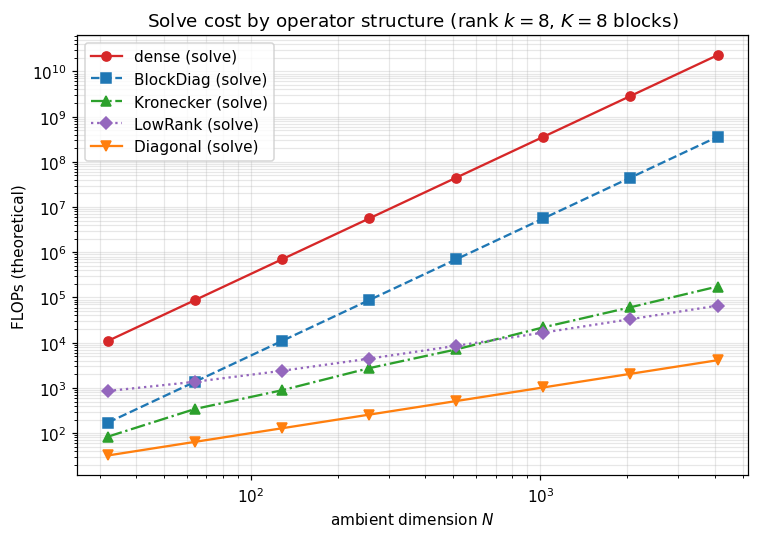

In [7]:
Ns = np.array([32, 64, 128, 256, 512, 1024, 2048, 4096])
k = 8
K_blocks = 8

def costs(N):
    n = m = int(np.sqrt(N))
    b = N // K_blocks
    return {
        "dense (solve)":      (1/3) * N**3,
        "BlockDiag (solve)":  K_blocks * (1/3) * b**3,
        "Kronecker (solve)":  (1/3) * (n**3 + m**3),
        "LowRank (solve)":    2*N*k + (2/3) * k**3,
        "Diagonal (solve)":   N,
    }

curves = {label: [] for label in costs(Ns[0])}
for N in Ns:
    for label, val in costs(N).items():
        curves[label].append(val)

fig, ax = plt.subplots(figsize=(7, 5))
styles = {
    "dense (solve)":     ("C3", "-",  "o"),
    "BlockDiag (solve)": ("C0", "--", "s"),
    "Kronecker (solve)": ("C2", "-.", "^"),
    "LowRank (solve)":   ("C4", ":",  "D"),
    "Diagonal (solve)":  ("C1", "-",  "v"),
}
for label, vals in curves.items():
    color, ls, m_ = styles[label]
    ax.loglog(Ns, vals, ls, color=color, marker=m_, label=label)
ax.set_xlabel("ambient dimension $N$")
ax.set_ylabel("FLOPs (theoretical)")
ax.set_title("Solve cost by operator structure (rank $k=8$, $K=8$ blocks)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 9. Which operator do I reach for?

A short flowchart for picking structure when you build a covariance:

| If your covariance looks like... | Use |
|---|---|
| A noise term $\sigma^2 I$ | `IdentityLinearOperator` (or scaled) |
| Per-coordinate variances, no cross-correlation | `DiagonalLinearOperator` |
| A kernel on a $d_1\times d_2$ tensor-product grid | `Kronecker(K_1, K_2)` |
| Independent groups (multi-output, batched GPs) | `BlockDiag(K_1, \dots, K_G)` |
| A cheap base plus $k$ data-driven directions (inducing points, posterior update) | `LowRankUpdate` / `low_rank_plus_diag` / `low_rank_plus_identity` |
| Combinations of the above | nest them — `gaussx` propagates structure through composition |

The remaining 1.A notebooks fill in the rest of the catalog: 1.2 lazy algebra (sums/products/scaling), 1.3 KroneckerSum vs SumKronecker, 1.4 Toeplitz, 1.5 BlockTriDiag, 1.6 MaskedOperator. The next sections of *this* notebook (§10–§13) cover the structural-tag system that lets `gaussx` dispatch automatically across the entire catalog.

A reading hint: when you see a covariance in a paper, name its operator type out loud before reading the algorithm. Half the time the algorithm *is* the dispatch — and the structured cost is already in the table above.

## 10. How `gaussx` knows which algorithm to use — the two-tiered dispatch system

Every operator above carries a *type* (`Diagonal`, `Kronecker`, `BlockDiag`, `LowRankUpdate`, `MatrixLinearOperator`) and a `frozenset` of **structural tags** (`positive_semidefinite_tag`, `symmetric_tag`, `diagonal_tag`, `kronecker_tag`, `low_rank_tag`, …). `gaussx`'s primitives use these in two complementary ways:

1. **`isinstance` dispatch** in `solve` / `logdet` / `cholesky` — the *class* picks the algorithm. `solve` is essentially:

```python
def solve(operator, b):
    if isinstance(operator, lx.DiagonalLinearOperator): return _solve_diagonal(operator, b)
    if isinstance(operator, BlockDiag):                 return _solve_block_diag(operator, b)
    if isinstance(operator, Kronecker):                 return _solve_kronecker(operator, b)
    if isinstance(operator, LowRankUpdate):             return _solve_low_rank(operator, b)
    ...
    return _solve_fallback(operator, b)   # generic Cholesky / LU
```

2. **Tag predicates** — the *property* picks the inner solver inside a recipe. `is_positive_semidefinite(op)` decides Cholesky vs LU; `is_symmetric(op)` decides eigh vs eig; `is_diagonal(op)` collapses to element-wise. Predicates are `functools.singledispatch` functions that each operator type registers via `@lx.is_symmetric.register(MyType)`.

**Class for *which algorithm*. Tags for *which solver inside the algorithm*.** The two are deliberately complementary: class identity is the recipe; tags are the property assertions that recipes consult.

## 11. Tag inventory + what the basics advertise

The full tag catalog (re-exported from `gaussx._tags`):

| Source | Tag | Meaning |
|---|---|---|
| lineax | `symmetric_tag` | $A = A^\top$ |
| lineax | `diagonal_tag` | $A_{ij} = 0$ for $i\neq j$ |
| lineax | `tridiagonal_tag` | $A_{ij} = 0$ for $\|i-j\|>1$ |
| lineax | `unit_diagonal_tag` | $A_{ii} = 1$ |
| lineax | `lower_triangular_tag` / `upper_triangular_tag` | the obvious |
| lineax | `positive_semidefinite_tag` / `negative_semidefinite_tag` | $\pm v^\top A v \geq 0$ |
| gaussx | `kronecker_tag` | $A = B\otimes C$ |
| gaussx | `block_diagonal_tag` | $A = \mathrm{diag}(B_1,\dots,B_K)$ |
| gaussx | `low_rank_tag` | $A = M + UDV^\top$ |
| gaussx | `kronecker_sum_tag`, `block_tridiagonal_tag` | introduced in 1.3 / 1.5 |

Each comes with a matching predicate (`is_symmetric`, `is_kronecker`, etc.). Each operator class registers itself for the predicates it satisfies. The next cell builds one of every operator type from §2–§6 and queries the predicates that are relevant at this point in the tour.

In [8]:
import gaussx as gx
from gaussx._operators._low_rank_update import low_rank_plus_identity

kA, kB = jax.random.split(jax.random.PRNGKey(11))
A_psd = psd_op(random_psd(kA, 4))
B_psd = psd_op(random_psd(kB, 3))

basics_ops = {
    "Identity":            lx.IdentityLinearOperator(jax.ShapeDtypeStruct((4,), jnp.float64)),
    "Diagonal (positive)": lx.DiagonalLinearOperator(jnp.array([1.0, 2.0, 3.0])),
    "Dense PSD":           A_psd,
    "Kronecker(A, B)":     Kronecker(A_psd, B_psd),
    "BlockDiag(A, B)":     BlockDiag(A_psd, B_psd),
    "LowRankUpdate":       low_rank_plus_identity(jax.random.normal(jax.random.PRNGKey(12), (6, 2))),
}

predicates = [
    ("symmetric",   lx.is_symmetric),
    ("diagonal",    lx.is_diagonal),
    ("PSD",         lx.is_positive_semidefinite),
    ("kronecker",   gx.is_kronecker),
    ("block-diag",  gx.is_block_diagonal),
    ("low-rank",    gx.is_low_rank),
]

header = f"{'operator':<22s}" + "".join(f"{n:>11s}" for n, _ in predicates)
print(header)
print("-" * len(header))
for name, op in basics_ops.items():
    cells_ = []
    for _, fn in predicates:
        try:
            cells_.append("✓" if fn(op) else "·")
        except Exception:
            cells_.append("?")
    print(f"{name:<22s}" + "".join(f"{v:>11s}" for v in cells_))

operator                symmetric   diagonal        PSD  kronecker block-diag   low-rank
----------------------------------------------------------------------------------------
Identity                        ✓          ✓          ✓          ·          ·          ·
Diagonal (positive)             ✓          ✓          ·          ·          ·          ·
Dense PSD                       ✓          ·          ✓          ·          ·          ·
Kronecker(A, B)                 ✓          ·          ✓          ✓          ·          ·
BlockDiag(A, B)                 ✓          ·          ✓          ·          ✓          ·
LowRankUpdate                   ✓          ·          ✓          ·          ·          ✓


## 12. Watching `solve` find the recipe — dispatch tracing

A small experiment: monkey-patch each `_solve_*` branch to record when it fires, then call `gaussx.solve` on each operator. The recorded branch is the recipe `gaussx` chose. Every structured operator routes to its own recipe; the dense PSD case falls through to `_solve_fallback` (which delegates to lineax's Cholesky / LU autosolver).

In [9]:
import gaussx._primitives._solve as _solve_mod

original = {}
fired = []
for fn_name in ["_solve_diagonal", "_solve_block_diag", "_solve_kronecker",
                "_solve_low_rank", "_solve_fallback"]:
    original[fn_name] = getattr(_solve_mod, fn_name)
    def make_traced(name, original_fn):
        def traced(*args, **kwargs):
            fired.append(name)
            return original_fn(*args, **kwargs)
        return traced
    setattr(_solve_mod, fn_name, make_traced(fn_name, original[fn_name]))

print(f"{'operator':<18s}  →  branch fired")
print("-" * 48)
for name, op in basics_ops.items():
    fired.clear()
    b = jnp.ones(op.in_size())
    _ = solve(op, b)
    print(f"{name:<18s}  →  {fired[0] if fired else '(no branch)'}")

# Restore
for fn_name, fn in original.items():
    setattr(_solve_mod, fn_name, fn)

operator            →  branch fired
------------------------------------------------
Identity            →  _solve_fallback
Diagonal (positive)  →  _solve_diagonal


Dense PSD           →  _solve_fallback


Kronecker(A, B)     →  _solve_kronecker


BlockDiag(A, B)     →  _solve_block_diag


LowRankUpdate       →  _solve_low_rank


## 13. Bring your own operator — extending the system

The dispatch system is **open for extension**. Three steps to plug a new operator type into `gaussx`:

1. Subclass `lx.AbstractLinearOperator` with the required methods (`mv`, `as_matrix`, `transpose`, `in_structure`, `out_structure`).
2. Register tag predicates for any properties your operator advertises (`@lx.is_symmetric.register(MyType)`, `@gx.is_low_rank.register(MyType)`, …).
3. Optionally provide a fast primitive recipe — a function the user calls directly, or a `singledispatch` registration on a custom dispatcher.

The example below builds a **circulant operator** — like Toeplitz but with periodic boundary conditions, common for fully-periodic domains in spectral GP regression (annual cycles on a daily grid, longitudinal kernels on a sphere). Circulant matrices are diagonalized by the DFT, so solve and logdet are pure FFT operations costing $O(n\log n)$. This is exactly the pattern a domain expert follows to add a Slepian-localized kernel, a stochastic-PDE precision, or a custom SDE-discretization for their corner of geophysics.

In [10]:
import equinox as eqx
from jaxtyping import Float, Array

# Step 1: subclass AbstractLinearOperator
class Circulant(lx.AbstractLinearOperator):
    # C_{ij} = c_{(i-j) mod n}; matvec C v = IFFT(FFT(c) * FFT(v))  -- O(n log n)
    column: Float[Array, " n"]
    _size: int = eqx.field(static=True)
    tags: frozenset[object] = eqx.field(static=True)

    def __init__(self, column, *, tags=frozenset()):
        self.column = jnp.asarray(column)
        self._size = self.column.shape[0]
        if not isinstance(tags, frozenset):
            tags = frozenset({tags})
        self.tags = tags

    def mv(self, v):
        return jnp.fft.irfft(jnp.fft.rfft(self.column) * jnp.fft.rfft(v),
                             n=self._size).real

    def as_matrix(self):
        idx = (jnp.arange(self._size)[:, None] - jnp.arange(self._size)[None, :]) % self._size
        return self.column[idx]

    def transpose(self):
        flipped = jnp.concatenate([self.column[:1], self.column[::-1][:-1]])
        return Circulant(flipped, tags=lx.transpose_tags(self.tags))

    def in_structure(self):
        return jax.ShapeDtypeStruct((self._size,), self.column.dtype)
    def out_structure(self):
        return jax.ShapeDtypeStruct((self._size,), self.column.dtype)

# Step 2: register tag predicates
@lx.is_symmetric.register(Circulant)
def _(op: Circulant) -> bool: return lx.symmetric_tag in op.tags

@lx.is_positive_semidefinite.register(Circulant)
def _(op: Circulant) -> bool: return lx.positive_semidefinite_tag in op.tags

# Step 3: a fast custom solve via FFT-eigenvalue division
def circulant_solve(op: Circulant, b):
    eigs = jnp.fft.rfft(op.column)
    return jnp.fft.irfft(jnp.fft.rfft(b) / eigs, n=op._size).real

# Demo: stationary periodic kernel on a regular ring (annual cycle on a 64-point year)
n_ring = 64
t = jnp.linspace(0, 2*jnp.pi, n_ring, endpoint=False)
ell = 0.6
col_circ = jnp.exp(-2 * jnp.sin((t - t[0]) / 2)**2 / ell**2) + 1e-3 * (jnp.arange(n_ring) == 0)
C = Circulant(col_circ, tags=frozenset({lx.symmetric_tag, lx.positive_semidefinite_tag}))

print(f"Circulant operator built ({n_ring} x {n_ring})")
print(f"  is_symmetric            : {lx.is_symmetric(C)}")
print(f"  is_positive_semidefinite: {lx.is_positive_semidefinite(C)}")

v_circ = jax.random.normal(jax.random.PRNGKey(99), (n_ring,))
err_mv = jnp.linalg.norm(C.mv(v_circ) - C.as_matrix() @ v_circ)
print(f"  matvec error (FFT vs dense): {err_mv:.2e}")

b_circ = jax.random.normal(jax.random.PRNGKey(98), (n_ring,))
err_solve = jnp.linalg.norm(circulant_solve(C, b_circ) - jnp.linalg.solve(C.as_matrix(), b_circ))
print(f"  custom FFT-solve error      : {err_solve:.2e}")

Circulant operator built (64 x 64)
  is_symmetric            : True
  is_positive_semidefinite: True


  matvec error (FFT vs dense): 7.09e-15


  custom FFT-solve error      : 3.71e-09


## 14. Class vs tag — when to use which

A short style guide for picking between `isinstance(op, MyType)` and `is_my_property(op)`:

| Situation | Prefer |
|---|---|
| Selecting an algorithm in a primitive (`solve`, `logdet`) | `isinstance` — class identity = recipe identity |
| Querying a property inside a recipe (PSD? symmetric?) | tag predicate — independent of how the property arose |
| Composing operators where the composite's class differs from operands (`SumOperator(Kron, Kron)`) | tag predicate — the composite is `SumOperator`, not `Kronecker`, but the property of being symmetric / PSD propagates |
| Extending the system from outside | both — register your class for `isinstance` checks and register tag predicates so existing primitives recognize your operator's properties |
| Performance-sensitive inner loops | `isinstance` — `singledispatch` involves a Python function call; an `if isinstance` chain is JIT-friendly |

The reason `gaussx` uses `isinstance` for `solve` (not `singledispatch`) is the last point: keeping the dispatch in an `if`-chain inside a single function lets JAX trace through it cleanly without per-type closure overhead. Tag predicates *are* `singledispatch` because they're called outside hot inner loops — during construction, structural inference, and user-facing introspection.

That closes the operator-basics tour. The next notebooks build on this same dispatch backbone: 1.2 introduces lazy algebra (`Sum` / `Scaled` / `Product`) whose tag-propagation rules are critical for getting the right primitives to fire on composites; 1.3–1.6 introduce the remaining structured leaves (`KroneckerSum`, `SumKronecker`, `Toeplitz`, `BlockTriDiag`, `MaskedOperator`), each of which registers its own class branch and tag predicates following exactly the pattern in §13.